<a href="https://colab.research.google.com/github/Premanshukusre/Network-Anomaly-Detection-UNSW-NB15/blob/main/models/XGBoost_UNSW_NB15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Prathamesh Deshmukh

Roll No: CS23115

Subject: Machine Learning

Topic: Network Anomaly Detection

Dataset: UNSW-NB15

Model Used: XGBoost



**AIM**

To implement the XGBoost algorithm on the UNSW-NB15 dataset for detecting network anomalies and improving classification accuracy.

**DATASET DESCRIPTION**

The UNSW-NB15 dataset contains network traffic data with both normal and attack activities. It includes features like protocol, service, and statistical attributes used for intrusion detection.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/ML Dataset/UNSW_NB15_training-set.csv"
df = pd.read_csv(path)

df.head()

Mounted at /content/drive


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
# Drop unnecessary columns
df = df.drop(['id', 'attack_cat'], axis=1, errors='ignore')

# Separate features & target
X = df.drop('label', axis=1)
y = df['label']

# Encode categorical data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9776522742454606
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      7418
           1       0.99      0.97      0.98      9049

    accuracy                           0.98     16467
   macro avg       0.98      0.98      0.98     16467
weighted avg       0.98      0.98      0.98     16467



In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9776522742454606
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      7418
           1       0.99      0.97      0.98      9049

    accuracy                           0.98     16467
   macro avg       0.98      0.98      0.98     16467
weighted avg       0.98      0.98      0.98     16467



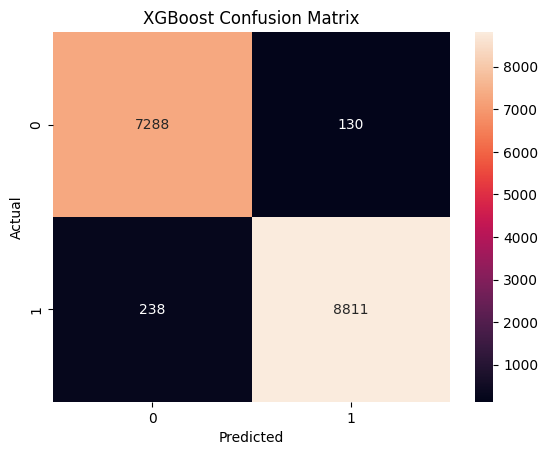

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

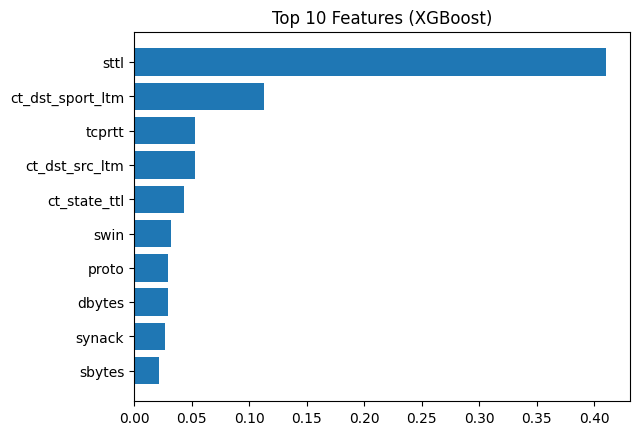

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False).head(10)

plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Features (XGBoost)")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

In [5]:
# Drop columns
df = df.drop(['id', 'attack_cat'], axis=1, errors='ignore')

# Encode categorical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Define X and y
X = df.drop('label', axis=1)
y = df['label']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train model
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Prediction
y_pred = xgb.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report (same like your output)
print(classification_report(y_test, y_pred))

Accuracy: 0.9780971659919029
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     11147
           1       0.98      0.98      0.98     13553

    accuracy                           0.98     24700
   macro avg       0.98      0.98      0.98     24700
weighted avg       0.98      0.98      0.98     24700

